# ML/02 — Clustering

K-means on PCA-reduced features to find the distinct environmental archetypes
of the Emerald Triangle.

**No labels.** The clusters emerge from the landscape itself. After fitting,
we interpret each cluster by its feature profile and map it spatially —
the hypothesis is that one or more clusters will correspond to the terrain
and climate conditions where cannabis cultivation concentrates.

**Pipeline:**
1. Elbow + silhouette to select K
2. K-means on PC scores (6 PCs, 90% variance)
3. Cluster profiles — radar plots + feature means
4. Spatial map of clusters
5. Cannabis suitability interpretation

**Outputs:**
- `data/processed/clusters.pkl` — cell_id + cluster label
- `img/ML02_elbow.png`
- `img/ML02_cluster_map.png`
- `img/ML02_cluster_profiles.png`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
IMG  = Path('../img')

RANDOM_STATE = 746837645

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Load PCA coords

In [2]:
pca_df   = pd.read_pickle(PROC / 'pca_coords.pkl')
features = pd.read_pickle(PROC / 'features.pkl')
hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')

PC_COLS = [c for c in pca_df.columns if c.startswith('PC')][:6]

# Standardize PC scores to unit variance before clustering.
# PCA scores have variance = eigenvalue, so PC1 (55%) dominates K-means
# distance and clustering just slices along the coast gradient.
# Equalizing variance gives all 6 PCs equal weight.
from sklearn.preprocessing import StandardScaler
X_raw = pca_df[PC_COLS].values
X = StandardScaler().fit_transform(X_raw)

print(f'Clustering on {X.shape[1]} PCs (unit-variance equalized), {X.shape[0]:,} cells')
print(f'Per-PC std before equalization: {X_raw.std(axis=0).round(2)}')
print(f'Per-PC std after  equalization: {X.std(axis=0).round(2)}')

Clustering on 6 PCs (unit-variance equalized), 8,648 cells
Per-PC std before equalization: [3.56 1.95 1.4  1.06 0.98 0.92]
Per-PC std after  equalization: [1. 1. 1. 1. 1. 1.]


## 2. Elbow + silhouette — select K

In [3]:
K_range = range(2, 11)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels, sample_size=2000, random_state=746837645))
    print(f'  K={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.3f}')

  K=2  inertia=43,662  silhouette=0.345
  K=3  inertia=37,305  silhouette=0.210
  K=4  inertia=32,228  silhouette=0.226
  K=5  inertia=28,321  silhouette=0.233
  K=6  inertia=24,966  silhouette=0.241
  K=7  inertia=22,113  silhouette=0.246
  K=8  inertia=20,419  silhouette=0.245
  K=9  inertia=19,398  silhouette=0.230
  K=10  inertia=18,444  silhouette=0.225


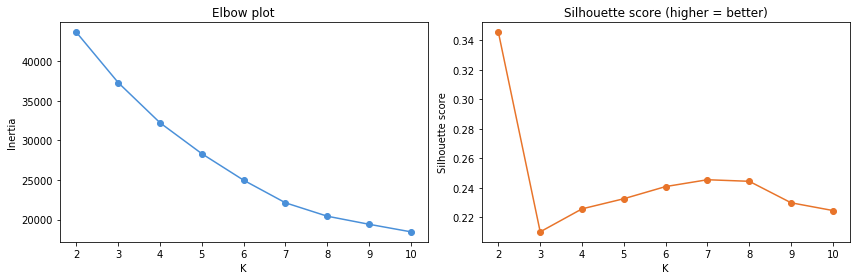


Choose K where elbow bends AND silhouette is high.
Set K below and continue.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='#4a90d9')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow plot')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), sil_scores, 'o-', color='#e8742a')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score (higher = better)')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('../img/ML02_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Choose K where elbow bends AND silhouette is high.')
print('Set K below and continue.')

## 3. Fit final K-means

Set `K` based on the elbow/silhouette plots above.

In [5]:
K = 7  

km_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=50)
labels = km_final.fit_predict(X)

pca_df['cluster'] = labels
features['cluster'] = labels

print(f'K={K} final clustering')
print(pd.Series(labels).value_counts().sort_index().rename('n_cells').to_string())

K=7 final clustering
0    1924
1    1815
2     269
3     638
4    1230
5    1399
6    1373


## 4. Cluster profiles

In [6]:
feature_cols = [c for c in features.columns if c not in ('cell_id', 'cluster')]

# Mean of raw (unscaled) features per cluster
profiles = features.groupby('cluster')[feature_cols].mean()

# Highlight cannabis-relevant features
cannabis_features = ['elev_mean', 'slope_mean', 'tmean', 'ffd', 'gdd',
                     'ppt', 'vpdmax', 'ph', 'soc', 'drainage_score'
                     if 'drainage_score' in feature_cols else 'sand']
cannabis_features = [f for f in cannabis_features if f in feature_cols]

print('Cluster profiles (cannabis-relevant features):')
print(profiles[cannabis_features].round(1).to_string())

Cluster profiles (cannabis-relevant features):
         elev_mean  slope_mean  tmean    ffd     gdd     ppt  vpdmax    ph    soc   sand
cluster                                                                                 
0            527.4        16.8   13.8  329.2  1394.8  1102.2  1567.6  58.4  404.8  404.7
1            387.7        18.0   12.4  330.1   872.1  1523.2  1096.7  54.9  765.6  304.8
2            176.8         7.5   11.6  299.8   738.9  1123.5  1049.1  25.0  280.9  158.2
3              0.0         0.0    0.6   15.8     0.0    59.1    48.5   0.1    1.1    0.8
4           1458.4        18.6   11.3  306.2   471.8  1458.3  1178.2  57.8  644.8  464.7
5            901.9        22.6   12.5  316.9   920.2  1367.5  1365.5  58.5  554.3  407.0
6            779.4        21.6   12.7  320.1   970.7  1347.5  1353.4  58.1  582.5  394.6


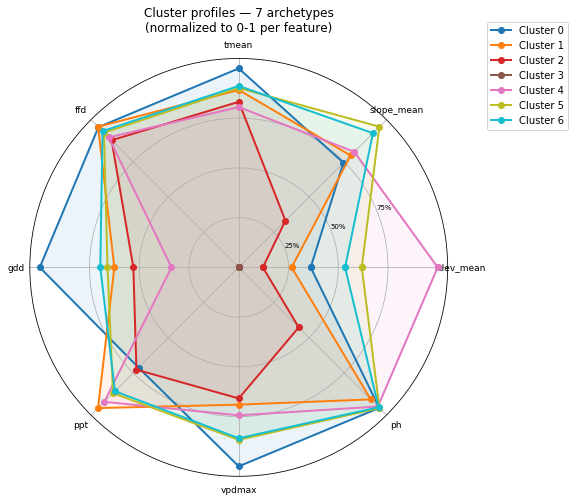

In [7]:
# Radar plot — one spoke per feature, one line per cluster
from matplotlib.patches import FancyArrowPatch

radar_features = cannabis_features[:8]   # limit spokes for readability
n_feat = len(radar_features)
angles = np.linspace(0, 2*np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

# Normalize each feature 0-1 for radar
radar_df = profiles[radar_features].copy()
radar_df = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

colors = plt.cm.tab10(np.linspace(0, 1, K))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for k_idx in range(K):
    vals = radar_df.loc[k_idx].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=colors[k_idx], label=f'Cluster {k_idx}')
    ax.fill(angles, vals, alpha=0.08, color=colors[k_idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%', '50%', '75%'], fontsize=7)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title(f'Cluster profiles — {K} archetypes\n(normalized to 0-1 per feature)', fontsize=12)

plt.tight_layout()
plt.savefig('../img/ML02_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Spatial map

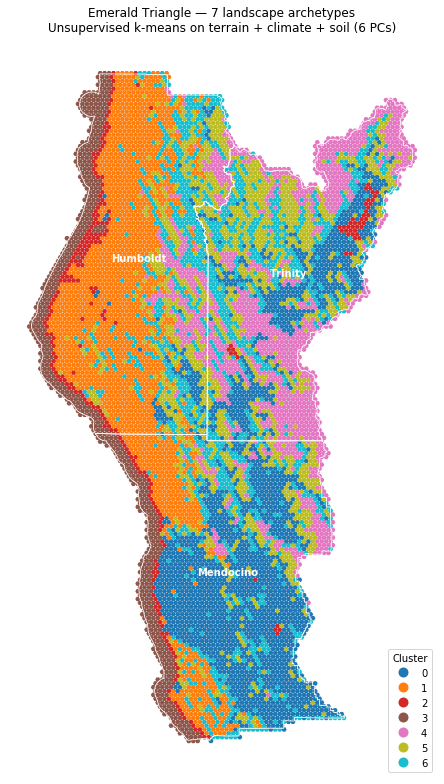

Saved img/ML02_cluster_map.png


In [8]:
clusters_geo = hex_grid.merge(pca_df[['cell_id', 'cluster']], on='cell_id')
emerald      = gpd.read_file(RAW / 'emerald_counties.gpkg')

fig, ax = plt.subplots(figsize=(10, 11))
clusters_geo.plot(
    column='cluster', ax=ax,
    categorical=True, cmap='tab10',
    legend=True,
    legend_kwds={'title': 'Cluster', 'loc': 'lower right'},
    linewidth=0,
)
emerald.boundary.plot(ax=ax, edgecolor='white', linewidth=0.8)
for _, row in emerald.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['NAME'], (c.x, c.y), ha='center', fontsize=10, color='white',
                fontweight='bold')

ax.set_title(
    f'Emerald Triangle — {K} landscape archetypes\n'
    f'Unsupervised k-means on terrain + climate + soil (6 PCs)',
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../img/ML02_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML02_cluster_map.png')

## 6. Interpret clusters

Look at the map and profiles together. For each cluster ask:
- Where is it? Coast, interior valley, high ridge, river bottom?
- What are the climate stats? (tmean, ffd, gdd, ppt)
- Is the VPD in the cannabis mold-risk zone (>15 hPa peak)?
- What elevation band?

Label each cluster manually in the dict below.

In [14]:
# Fill in after inspecting map + profiles
CLUSTER_LABELS = {
  0: 'Cannabis Suitability Zone',   # highest GDD, warmest, moderate PPT    
  1: 'Moist Low-Slope',             # high PPT, low GDD, acidic soils       
  2: 'Rock/Water Edge',             # pH 2.5 actual — anomalous, exclude    
  3: 'Null/Ocean',                  # no-data cells — elev=0, GDD=0         
  4: 'High Alpine',                 # elev 1458m, GDD 471 — too cold        
  5: 'Cool Upper Slope',            # secondary ring — cooler, steeper      
  6: 'Moderate Upper Slope',        # secondary ring — similar to 5,        
# slightly warmer                                                               
}  

clusters_geo['archetype'] = clusters_geo['cluster'].map(CLUSTER_LABELS)
print('Cluster sizes:')
print(clusters_geo['archetype'].value_counts().to_string())

Cluster sizes:
Cannabis Suitability Zone    1924
Moist Low-Slope              1815
Cool Upper Slope             1399
Moderate Upper Slope         1373
High Alpine                  1230
Null/Ocean                    638
Rock/Water Edge               269


In [17]:
clusters_geo

,cell_id,geometry,cluster,archetype
0,cell_00001,"POLYGON ((446465.420 4289847.141, 445888.070 4...",3,Null/Ocean
1,cell_00002,"POLYGON ((448465.420 4289847.141, 447888.070 4...",3,Null/Ocean
2,cell_00003,"POLYGON ((450465.420 4289847.141, 449888.070 4...",3,Null/Ocean
3,cell_00006,"POLYGON ((456465.420 4289847.141, 455888.070 4...",0,Cannabis Suitability Zone
4,cell_00008,"POLYGON ((445465.420 4291579.191, 444888.070 4...",3,Null/Ocean
...,...,...,...,...
8643,cell_08917,"POLYGON ((428465.420 4591223.981, 427888.070 4...",6,Moderate Upper Slope
8644,cell_08918,"POLYGON ((430465.420 4591223.981, 429888.070 4...",1,Moist Low-Slope
8645,cell_08919,"POLYGON ((432465.420 4591223.981, 431888.070 4...",1,Moist Low-Slope
8646,cell_08920,"POLYGON ((434465.420 4591223.981, 433888.070 4...",6,Moderate Upper Slope


## 7. Save

In [15]:
out = PROC / 'clusters.pkl'
pca_df[['cell_id', 'cluster']].to_pickle(out)
print(f'Saved {out}')
print()
print('Next: ML/03_ndvi_regression.ipynb — what drives NDVI within each cluster?')

Saved ../data/processed/clusters.pkl

Next: ML/03_ndvi_regression.ipynb — what drives NDVI within each cluster?


Suitability zone: 1,924 cells (22.2% of study area)
Area: 6325 km²


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


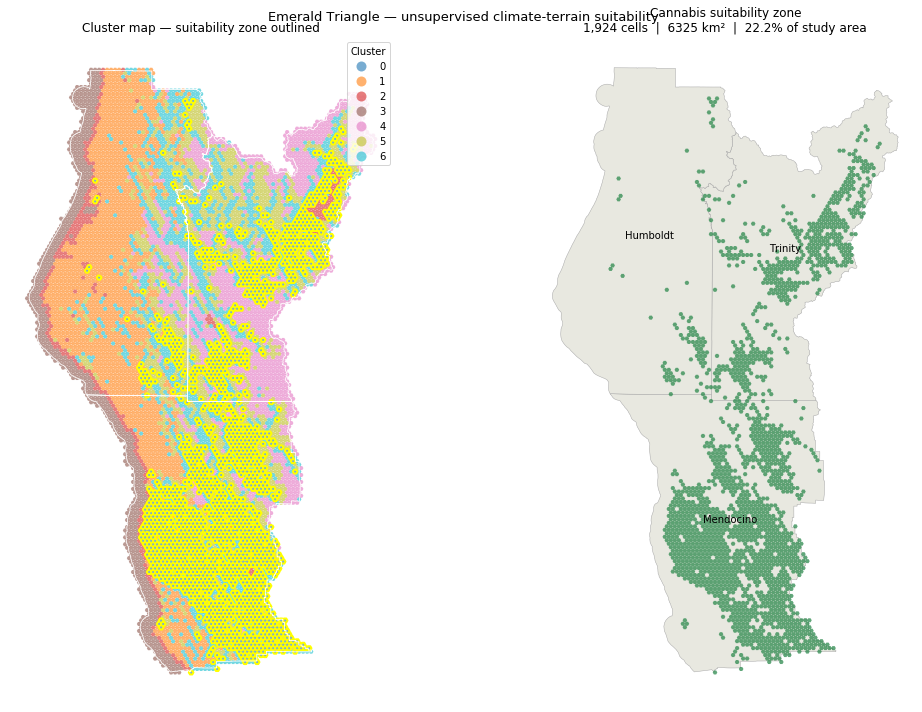

Saved img/ML02_suitability_zone.png
Saved data/processed/suitability_zone.gpkg
Saved data/processed/cannabis_cells.gpkg


In [16]:
# Extract cluster 2 (Cannabis country) and dissolve to a single suitability polygon

cannabis_cells = clusters_geo[clusters_geo['cluster'] == 0].copy()

# Dissolve all cluster-2 hex cells into one polygon
suitability_poly = cannabis_cells.dissolve()[['geometry']].copy()
suitability_poly['label'] = 'Cannabis suitability zone'
suitability_poly['n_cells'] = len(cannabis_cells)
suitability_poly['pct_area'] = len(cannabis_cells) / len(clusters_geo) * 100

print(f'Suitability zone: {len(cannabis_cells):,} cells '
      f'({suitability_poly.pct_area.iloc[0]:.1f}% of study area)')
print(f'Area: {suitability_poly.geometry.area.iloc[0] / 1e6:.0f} km²')

# Map: cluster 2 highlighted over the full cluster backdrop
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Left: cluster map with suitability outlined
clusters_geo.plot(column='cluster', ax=axes[0], categorical=True, cmap='tab10',
                  legend=True, legend_kwds={'title': 'Cluster'}, linewidth=0, alpha=0.6)
suitability_poly.boundary.plot(ax=axes[0], color='yellow', linewidth=2)
emerald.boundary.plot(ax=axes[0], edgecolor='white', linewidth=0.8)
axes[0].set_title('Cluster map — suitability zone outlined', fontsize=12)
axes[0].set_axis_off()

# Right: suitability zone only
emerald.plot(ax=axes[1], color='#e8e8e0', edgecolor='#aaaaaa', linewidth=0.5)
suitability_poly.plot(ax=axes[1], color='#2d8a4e', alpha=0.75)
for _, row in emerald.iterrows():
    c = row.geometry.centroid
    axes[1].annotate(row['NAME'], (c.x, c.y), ha='center', fontsize=10)
axes[1].set_title(
    f'Cannabis suitability zone\n'
    f'{len(cannabis_cells):,} cells  |  '
    f'{suitability_poly.geometry.area.iloc[0]/1e6:.0f} km²  |  '
    f'{suitability_poly.pct_area.iloc[0]:.1f}% of study area',
    fontsize=12
)
axes[1].set_axis_off()

plt.suptitle('Emerald Triangle — unsupervised climate-terrain suitability', fontsize=13)
plt.tight_layout()
plt.savefig('../img/ML02_suitability_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML02_suitability_zone.png')

# Save
suitability_poly.to_file(PROC / 'suitability_zone.gpkg', driver='GPKG')
cannabis_cells[['cell_id', 'cluster', 'geometry']].to_file(
    PROC / 'cannabis_cells.gpkg', driver='GPKG'
)
print('Saved data/processed/suitability_zone.gpkg')
print('Saved data/processed/cannabis_cells.gpkg')